# 베이스라인 보고서 그래프

[`docs/baseline-report.md`](../docs/baseline-report.md)에 들어가는 그림을
실험 산출물에서 다시 계산해 [`docs/figures/`](../docs/figures/)에 저장한다.

| 그림 | 내용 | 파일 이름 |
| ---- | ---- | --------- |
| 그림 1 | 탐지 성능 — 다섯 탐지기의 클래스별 AP | `baseline-report-detection-ap` |
| 그림 2 | 팁 적중률 곡선 — 거리 임계값 전 구간 | `baseline-report-hit-curve` |
| 그림 3 | 팁 오차 거리 분포 | `baseline-report-error-distribution` |
| 그림 4 | 학습 수렴 — 에포크별 val mAP@0.5:0.95 | `baseline-report-convergence` |
| 그림 5 | 라벨 할당 밀도 — GT 하나가 받는 양성 앵커 수 | `baseline-report-assignment` |
| 그림 6 | 헝가리안 정밀도–재현율 | `baseline-report-precision-recall` |
| 그림 7 | 속도 대 정확도 | `baseline-report-speed-accuracy` |

읽는 산출물은 여섯 곳이다.

- `baseline/cladnet/data/{model,results}/` — CLAD-Net 재구현
- `baseline/yolov8sclone/data/{model,results}/` — YOLOv8s 재구현
- `baseline/yolo26clone/data/{model,results}/` — YOLO26 재구현
- `baseline/yolov8s/data/{model,results}/`·`baseline/yolo26/data/{model,results}/` —
  `ultralytics` 참조 구현을 COCO 사전학습에서 파인튜닝한 두 회차
- `data/results/<dataset>/<target-mode>/monai/` — 루트 프로젝트(세그멘테이션 기반) 비교군
- 그림 5만은 파일이 아니라 **모델을 만들어 라벨 할당을 한 번 돌려** 잰다 (학습은 하지 않는다).
  참조 구현 두 회차는 재구현과 아키텍처가 같으므로 이 그림에서는 재구현 셋만 잰다.


In [1]:
from __future__ import annotations

import csv
import json
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

for candidate in (Path.cwd().resolve(), Path.cwd().resolve().parent):
    if (candidate / "ttd").is_dir():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Run the notebook from the repository root or notebook/")

FIGURE_DIR = REPO_ROOT / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INK = "#222222"

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 192,          # docs/figures/README.md: PNG는 2배 해상도(192 dpi)
    "savefig.bbox": "tight",
    "svg.fonttype": "none",      # SVG에 텍스트를 텍스트로 남겨 편집 가능하게 둔다
    "font.family": ["Noto Sans CJK KR", "NanumGothic", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.edgecolor": "#888888",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.unicode_minus": False,
})

# 한 아키텍처 = 한 색조. 재구현은 진한 색, 같은 아키텍처의 참조 구현(COCO 사전학습)은
# 같은 색의 옅은 톤이라 한눈에 짝이 보인다. 세그멘테이션 비교군은 회색 계열로 눌러 둔다.
COLOR = {
    "yolov8s": "#8fbde3",
    "yolov8sclone": "#1f6fb4",
    "yolo26": "#8ecdab",
    "yolo26clone": "#2e8b57",
    "cladnet": "#c0392b",
    "gaussian-tip": "#7f8c8d",
    "gradient-seg": "#b0b7bb",
}
LABEL = {
    "yolov8s": "YOLOv8s (참조)",
    "yolov8sclone": "YOLOv8s",
    "yolo26": "YOLO26 (참조)",
    "yolo26clone": "YOLO26",
    "cladnet": "CLAD-Net",
    "gaussian-tip": "tooltip-detector (gaussian-tip)",
    "gradient-seg": "tooltip-detector (gradient-seg)",
}
DATASETS = ("cholec80", "erop")
# 짝을 이루는 아키텍처끼리 붙여 둔다: 참조 구현 옆이 그 아키텍처의 재구현이다.
DETECTORS = ("yolov8s", "yolov8sclone", "yolo26", "yolo26clone", "cladnet")
#: COCO 사전학습에서 시작한 `ultralytics` 회차. 나머지 셋은 무작위 초기화다.
PRETRAINED = ("yolov8s", "yolo26")
#: 라벨 할당을 직접 잴 수 있는 모델. 참조 구현 둘은 아키텍처가 같은 재구현이 대신한다.
ASSIGNED = ("yolov8sclone", "yolo26clone", "cladnet")
SEGMENTATION = ("gaussian-tip", "gradient-seg")
MODELS = DETECTORS + SEGMENTATION


def mix(color: str, other: str, weight: float) -> str:
    """color를 other 쪽으로 weight만큼 섞은 hex 색을 돌려준다."""
    a, b = mpl.colors.to_rgb(color), mpl.colors.to_rgb(other)
    return mpl.colors.to_hex(tuple(x * (1 - weight) + y * weight for x, y in zip(a, b)))


def save(fig, name: str) -> None:
    """SVG(원본)와 PNG(문서 삽입용)를 같은 이름으로 저장한다."""
    for suffix in ("svg", "png"):
        path = FIGURE_DIR / f"{name}.{suffix}"
        fig.savefig(path)
        print(f"saved {path.relative_to(REPO_ROOT)}")

## 데이터 로딩

네 모델의 산출물을 같은 모양으로 읽어 둔다. 검출기 둘은 `baseline/<name>/data/` 아래,
세그멘테이션 비교군은 루트 `data/results/` 아래에 있고 디렉터리 구조가 다르다.

`per_tip.csv`는 네 모델 × 두 데이터셋 합계 약 85만 행이므로, 아래 셀에서 한 번만 훑어
필요한 집계(오차 거리 배열)만 메모리에 남긴다.

In [2]:
def summary_path(model: str, dataset: str) -> Path:
    if model in DETECTORS:
        return REPO_ROOT / "baseline" / model / "data" / "results" / dataset / "test" / "summary.json"
    return REPO_ROOT / "data" / "results" / dataset / model / "monai" / "summary.json"


def per_tip_path(model: str, dataset: str) -> Path:
    return summary_path(model, dataset).with_name("per_tip.csv")


def read_summary(model: str, dataset: str) -> dict:
    return json.loads(summary_path(model, dataset).read_text(encoding="utf-8"))


SUMMARY = {(m, d): read_summary(m, d) for m in MODELS for d in DATASETS}


def tip_block(model: str, dataset: str) -> dict:
    """검출기와 루트 프로젝트의 summary.json 구조 차이를 흡수한다."""
    payload = SUMMARY[(model, dataset)]
    return payload["tip"] if model in DETECTORS else payload


def hungarian_block(model: str, dataset: str, cap: int) -> dict:
    payload = SUMMARY[(model, dataset)]
    if model in DETECTORS:
        return payload["tip"]["hungarian"][f"{cap}px"]
    return payload["hungarian"]["distance_caps_px"][str(cap)]


def read_distances(model: str, dataset: str) -> tuple[np.ndarray, int]:
    """(매칭된 팁의 오차 거리, 전체 GT 팁 수). 놓친 팁은 배열에서 빠진다."""
    distances, total = [], 0
    with per_tip_path(model, dataset).open(newline="", encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            total += 1
            if row["missed"] == "0" and row["dist_px"] != "":
                distances.append(float(row["dist_px"]))
    return np.asarray(distances), total


DISTANCES = {(m, d): read_distances(m, d) for m in MODELS for d in DATASETS}
for (model, dataset), (values, total) in DISTANCES.items():
    print(f"{model:<14} {dataset:<9} GT {total:>7,}  matched {len(values):>7,}")

yolov8s        cholec80  GT 161,969  matched 151,699
yolov8s        erop      GT  50,718  matched  48,531
yolov8sclone   cholec80  GT 161,969  matched 147,676
yolov8sclone   erop      GT  50,718  matched  48,288
yolo26         cholec80  GT 161,969  matched 149,895
yolo26         erop      GT  50,718  matched  47,851
yolo26clone    cholec80  GT 161,969  matched 146,240
yolo26clone    erop      GT  50,718  matched  47,697
cladnet        cholec80  GT 161,969  matched 146,479
cladnet        erop      GT  50,718  matched  47,250
gaussian-tip   cholec80  GT 161,969  matched 149,855
gaussian-tip   erop      GT  50,718  matched  48,169
gradient-seg   cholec80  GT 161,969  matched 157,273
gradient-seg   erop      GT  50,718  matched  49,149


## 그림 1 — 탐지 성능 (클래스별 AP)

다섯 탐지기만 그린다. 세그멘테이션 비교군은 박스를 내놓지 않으므로 AP를 정의할 수 없다.

`tool`과 `tip`을 나눠 보는 것이 핵심이다. 보고서 §3.1이 짚는 "격차가 팁 클래스에서 벌어진다"는
관찰이 mAP 하나로는 보이지 않는다. 옅은 막대 둘은 COCO 사전학습에서 시작한 참조 구현이라,
바로 옆의 진한 막대(같은 아키텍처의 스크래치 재구현)와 짝지어 읽으면 사전학습의 몫이 보인다.


saved docs/figures/baseline-report-detection-ap.svg
saved docs/figures/baseline-report-detection-ap.png


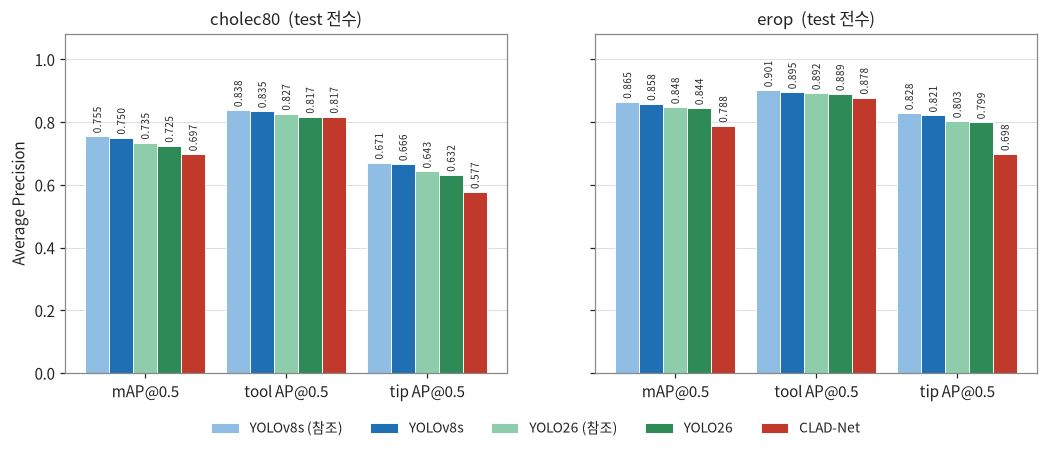

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0), sharey=True)

metrics = [("map50", "mAP@0.5"), ("tool", "tool AP@0.5"), ("tip", "tip AP@0.5")]
x = np.arange(len(metrics))
width = 0.17

for axis, dataset in zip(axes, DATASETS):
    # 막대 다섯 개가 겹치지 않도록 폭만큼씩 벌린다
    for offset, model in zip(np.linspace(-2 * width, 2 * width, len(DETECTORS)), DETECTORS):
        detection = SUMMARY[(model, dataset)]["detection"]
        values = [detection["map50"],
                  detection["per_class"]["tool"]["ap50"],
                  detection["per_class"]["tip"]["ap50"]]
        bars = axis.bar(x + offset, values, width, label=LABEL[model],
                        color=COLOR[model], edgecolor="white", linewidth=0.6)
        axis.bar_label(bars, fmt="%.3f", fontsize=6.5, padding=2, rotation=90)
    axis.set_xticks(x, [label for _, label in metrics])
    axis.set_title(f"{dataset}  (test 전수)")
    axis.set_ylim(0, 1.08)
    axis.grid(axis="y", color="#dddddd", linewidth=0.6)
    axis.set_axisbelow(True)

axes[0].set_ylabel("Average Precision")
# 막대가 축을 거의 채우므로 범례는 그림 아래로 뺀다
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           ncol=len(DETECTORS), fontsize=9, frameon=False)
save(fig, "baseline-report-detection-ap")

## 그림 2 — 팁 적중률 곡선

보고서의 표는 Hit@10 / @20 / @50 세 점만 싣는다. `per_tip.csv`에는 거리가 전부 들어 있으므로
**임계값 전 구간의 누적 곡선**을 그릴 수 있고, 그래야 "검출기는 앞에서 앞서고 세그멘테이션은
뒤에서 따라잡는다"는 교차가 드러난다.

세로축은 **전체 GT 팁** 대비 비율이다. 곡선이 오른쪽 끝에서 도달하는 높이가 곧
`100 % − 탐지 실패율`이다.

saved docs/figures/baseline-report-hit-curve.svg
saved docs/figures/baseline-report-hit-curve.png


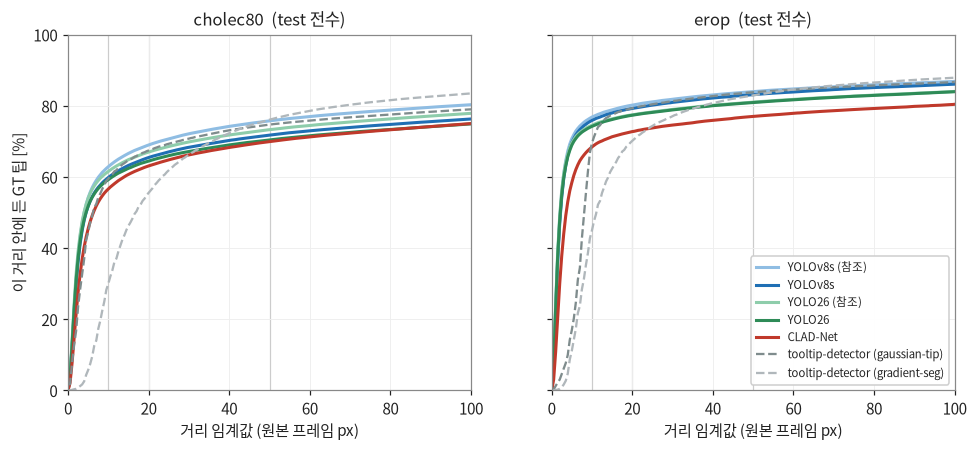

In [4]:
thresholds = np.arange(0, 100.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), sharey=True)

for axis, dataset in zip(axes, DATASETS):
    for model in MODELS:
        values, total = DISTANCES[(model, dataset)]
        curve = [100.0 * np.count_nonzero(values <= t) / total for t in thresholds]
        style = "-" if model in DETECTORS else "--"
        axis.plot(thresholds, curve, style, color=COLOR[model],
                  linewidth=2.0 if model in DETECTORS else 1.5, label=LABEL[model])
    for mark in (10, 20, 50):
        axis.axvline(mark, color="#cccccc", linewidth=0.8, zorder=0)
    axis.set_xlabel("거리 임계값 (원본 프레임 px)")
    axis.set_title(f"{dataset}  (test 전수)")
    axis.set_xlim(0, 100)
    axis.set_ylim(0, 100)
    axis.grid(color="#eeeeee", linewidth=0.6)
    axis.set_axisbelow(True)

axes[0].set_ylabel("이 거리 안에 든 GT 팁 [%]")
axes[1].legend(loc="lower right", framealpha=0.95, fontsize=7.5)
save(fig, "baseline-report-hit-curve")

## 그림 3 — 팁 오차 거리 분포

그림 2가 누적이라면 이쪽은 밀도다. 분포가 **이봉형**이라는 점 — 절반은 몇 px 안에 들어오고
나머지는 100 px 밖으로 흩어진다 — 이 일곱 모델 모두에서 관찰되며, 보고서 §6이 그 원인을
"다중 도구 프레임의 과소 탐지"로 지목한다.

분모는 매칭된 팁이고, 가로축은 로그 스케일이다.

saved docs/figures/baseline-report-error-distribution.svg
saved docs/figures/baseline-report-error-distribution.png


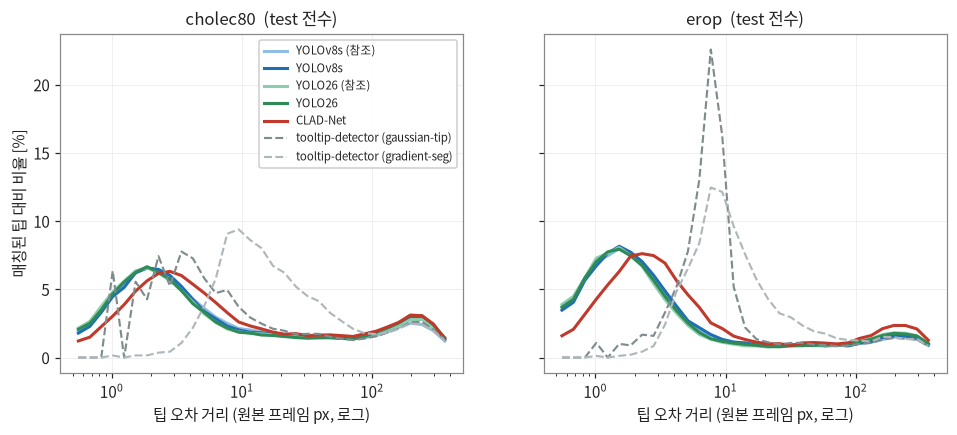

In [5]:
edges = np.logspace(np.log10(0.5), np.log10(400), 34)
centres = np.sqrt(edges[:-1] * edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0), sharey=True)

for axis, dataset in zip(axes, DATASETS):
    for model in MODELS:
        values, _ = DISTANCES[(model, dataset)]
        share = 100.0 * np.histogram(values, bins=edges)[0] / max(len(values), 1)
        style = "-" if model in DETECTORS else "--"
        axis.plot(centres, share, style, color=COLOR[model],
                  linewidth=2.0 if model in DETECTORS else 1.4, label=LABEL[model])
    axis.set_xscale("log")
    axis.set_xlabel("팁 오차 거리 (원본 프레임 px, 로그)")
    axis.set_title(f"{dataset}  (test 전수)")
    axis.grid(color="#eeeeee", linewidth=0.6)
    axis.set_axisbelow(True)

axes[0].set_ylabel("매칭된 팁 대비 비율 [%]")
axes[0].legend(loc="upper right", framealpha=0.95, fontsize=7.5)
save(fig, "baseline-report-error-distribution")

## 그림 4 — 학습 수렴

다섯 탐지기의 `metric.csv`를 에포크 전 구간 그린다. 세 가지가 드러난다.

- **초반 상승 속도** — 사전학습에서 시작한 참조 구현 둘이 가장 빠르고, 스크래치 재구현 둘이
  뒤따르며, CLAD-Net이 가장 느리다.
- **정점의 위치** — 참조 구현은 60〜110 에포크에서, 스크래치 재구현은 107〜125 에포크에서
  정점을 찍고 내려오지만(과적합), CLAD-Net은 150 에포크에서도 최고점이 끝에 있다.
- **곡선의 높이는 비교하지 않는다** — 두 계열이 서로 다른 val 표본(재구현 1,500 프레임,
  참조 구현 1,903〜1,914 프레임)을 서로 다른 검증 코드로 재기 때문이다. 계열이 다른 곡선의
  세로 위치를 직접 견주면 안 되고, 모델 간 비교는 같은 규칙으로 채점한 test 수치(그림 1〜3)로
  한다.


saved docs/figures/baseline-report-convergence.svg
saved docs/figures/baseline-report-convergence.png


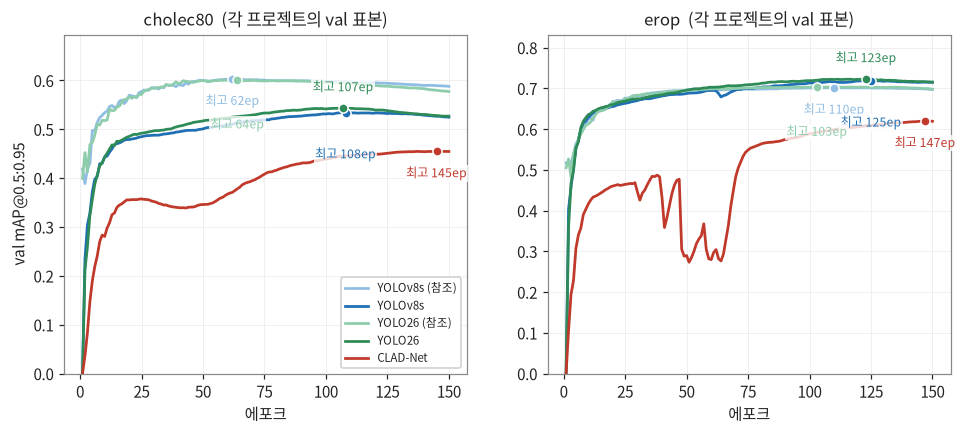

In [6]:
def read_curve(model: str, dataset: str) -> tuple[np.ndarray, np.ndarray]:
    path = REPO_ROOT / "baseline" / model / "data" / "model" / dataset / "metric.csv"
    with path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    return (np.array([int(r["epoch"]) for r in rows]),
            np.array([float(r["map50_95"]) for r in rows]))


# 최고점 주석이 서로 겹치므로 곡선마다 위아래 간격을 갈라 둔다
ANNOT_DY = {"yolov8s": -17, "yolov8sclone": -30, "yolo26": -32, "yolo26clone": 11,
            "cladnet": -17}

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))

for axis, dataset in zip(axes, DATASETS):
    for model in DETECTORS:
        epochs, fitness = read_curve(model, dataset)
        axis.plot(epochs, fitness, color=COLOR[model], linewidth=1.8, label=LABEL[model])
        best = int(np.argmax(fitness))
        axis.plot(epochs[best], fitness[best], "o", color=COLOR[model], markersize=6,
                  markeredgecolor="white", markeredgewidth=1.0, zorder=5)
        # 곡선이 다섯이라 주석이 남의 선 위에 얹히는 일이 생긴다. 흰 배경을 깔아
        # 어느 쪽이 위에 오더라도 글자가 읽히게 둔다.
        axis.annotate(f"최고 {epochs[best]}ep", (epochs[best], fitness[best]),
                      textcoords="offset points", xytext=(0, ANNOT_DY[model]), ha="center",
                      fontsize=8, color=COLOR[model], zorder=6,
                      bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.8))
    axis.set_xlabel("에포크")
    # val 표본이 계열마다 다르므로(재구현 1,500 / 참조 1,903〜1,914 프레임) 곡선의
    # 높이는 계열 안에서만 견준다.
    axis.set_title(f"{dataset}  (각 프로젝트의 val 표본)")
    axis.grid(color="#eeeeee", linewidth=0.6)
    axis.set_axisbelow(True)
    # 곡선 위로 올린 주석이 잘리지 않도록 위쪽에 여백을 둔다
    axis.set_ylim(0, max(read_curve(m, dataset)[1].max() for m in DETECTORS) * 1.15)

axes[0].set_ylabel("val mAP@0.5:0.95")
axes[0].legend(loc="lower right", framealpha=0.95, fontsize=7.5)
save(fig, "baseline-report-convergence")

## 그림 5 — 라벨 할당 밀도

이 그림만 파일이 아니라 **모델을 만들어 라벨 할당을 한 번 돌려** 만든다. 학습은 하지 않고,
`cholec80` val 400 프레임에 대해 "GT 상자 하나가 몇 개의 양성 앵커를 받는가"를 센다.

서브 프로젝트마다 가상환경이 다를 수 있으므로(각자의 `.venv`), 각 프로젝트의 인터프리터로
아래 스크립트를 따로 실행해 결과만 받아온다.

참조 구현 두 회차는 재구현과 **아키텍처도 할당기도 같으므로** 따로 재지 않는다. 이 그림이
재는 것은 학습된 가중치가 아니라 할당 규칙이며, 그 규칙은 구현체가 아니라 아키텍처가 정한다.

In [7]:
DIAGNOSTIC = r"""
import sys, json, torch, numpy as np
from collections import defaultdict
from torch.utils.data import DataLoader
sys.path.insert(0, PROJECT)
from common.dataset import SurgicalDetectionDataset, collate, TOOL_CLASS, TIP_CLASS
from common.inference import Detector, default_model_path
from common.loss import DetectionLoss

det = Detector(default_model_path('cholec80'), DEVICE); model = det.model.train()
KIND = KIND_PLACEHOLDER
crit = DetectionLoss(model, epochs=1) if KIND == 'e2e' else DetectionLoss(model)
ds = SurgicalDetectionDataset('cholec80', 'val', 640, augment=False, limit=400,
                              tip_box_size=det.tip_box_size)
dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=4, collate_fn=collate)
per_class = defaultdict(list); level_hits = defaultdict(lambda: defaultdict(int))

with torch.no_grad():
    for images, targets, _ in dl:
        images = images.to(DEVICE).float() / 255
        outs = model(images)
        counts = defaultdict(int)
        if KIND == 'anchor':
            strides = (8, 16, 32)
            for level, (bi, ai, gy, gx, tbox, tcls, anch) in enumerate(
                    crit._build_targets(outs, targets.to(DEVICE))):
                s = strides[level]
                for k in range(len(bi)):
                    cx = (float(gx[k]) + float(tbox[k, 0])) * s
                    cy = (float(gy[k]) + float(tbox[k, 1])) * s
                    counts[(int(bi[k]), int(tcls[k]), round(cx), round(cy))] += 1
                    level_hits[int(tcls[k])][level] += 1
            for key, n in counts.items():
                per_class[key[1]].append(n)
        else:
            from common.model import make_anchors
            if KIND == 'tal':
                bs = images.shape[0]
                sizes = [o.shape[2] * o.shape[3] for o in outs]
                flat = torch.cat([o.view(bs, crit.num_outputs, -1) for o in outs], 2)
                pd, ps = flat.split((crit.reg_max * 4, crit.num_classes), 1)
                ps = ps.permute(0, 2, 1).contiguous(); pd = pd.permute(0, 2, 1).contiguous()
                imgsz = torch.tensor(outs[0].shape[2:], device=DEVICE, dtype=ps.dtype) * crit.strides[0]
                ap, st = make_anchors(outs, crit.strides)
                prep = crit._preprocess(targets.to(DEVICE), bs, scale=imgsz[[1, 0]])
                gl, gb = prep.split((1, 4), 2); mask = gb.sum(2, keepdim=True).gt_(0)
                pb = crit._decode_boxes(ap, pd)
                assigner = crit.assigner
            else:
                # YOLO26: the head returns both branches. one2many is the one that
                # shapes the backbone, and its topk=10 matches YOLOv8's, so that is
                # the branch to compare. Boxes come out as four distances already
                # (reg_max=1), so there is no DFL integral to take.
                from common.model import dist2bbox
                branch = crit.one2many
                pred = outs['one2many']; feats = pred['feats']
                bs = pred['boxes'].shape[0]
                sizes = [f.shape[2] * f.shape[3] for f in feats]
                pd = pred['boxes'].permute(0, 2, 1).contiguous()
                ps = pred['scores'].permute(0, 2, 1).contiguous()
                imgsz = torch.tensor(feats[0].shape[2:], device=DEVICE, dtype=ps.dtype) * branch.strides[0]
                ap, st = make_anchors(feats, branch.strides)
                prep = branch._preprocess(targets.to(DEVICE), bs, scale=imgsz[[1, 0]])
                gl, gb = prep.split((1, 4), 2); mask = gb.sum(2, keepdim=True).gt_(0)
                pb = dist2bbox(pd, ap, xywh=False)
                assigner = branch.assigner
            _, _, _, fg, tidx = assigner(ps.detach().sigmoid(),
                (pb.detach() * st).type(gb.dtype), ap * st, gl, gb, mask)
            bounds = np.cumsum([0] + sizes)
            for b in range(bs):
                sel = fg[b]
                if not sel.any():
                    continue
                idx = tidx[b][sel].cpu().numpy()
                pos = torch.nonzero(sel).squeeze(1).cpu().numpy()
                cls = gl[b].squeeze(-1).cpu().numpy()
                for g in np.unique(idx):
                    if not bool(mask[b, g, 0]):
                        continue
                    per_class[int(cls[g])].append(int((idx == g).sum()))
                    for a in pos[idx == g]:
                        level_hits[int(cls[g])][int(np.searchsorted(bounds, a, 'right') - 1)] += 1

print('RESULT ' + json.dumps({
    'counts': {str(k): v for k, v in per_class.items()},
    'levels': {str(k): dict(v) for k, v in level_hits.items()},
}))
"""


def run_diagnostic(model: str, kind: str, device: str = "cuda:1") -> dict:
    project = REPO_ROOT / "baseline" / model
    script = (f"PROJECT={str(project)!r}\nDEVICE={device!r}\n"
              + DIAGNOSTIC.replace("KIND_PLACEHOLDER", repr(kind)))
    command = ["uv", "run", "--project", str(project), "python", "-c", script]
    if model in ("yolov8sclone", "yolo26clone"):      # 루트 가상환경을 그대로 쓴다
        command = ["uv", "run", "--project", str(REPO_ROOT), "python", "-c", script]
    completed = subprocess.run(command, cwd=project, capture_output=True, text=True)
    line = next((l for l in completed.stdout.splitlines() if l.startswith("RESULT ")), None)
    if line is None:
        raise RuntimeError(f"{model} diagnostic failed:\n{completed.stdout[-2000:]}\n{completed.stderr[-2000:]}")
    return json.loads(line[len("RESULT "):])


ASSIGNMENT = {
    "cladnet": run_diagnostic("cladnet", "anchor"),
    "yolov8sclone": run_diagnostic("yolov8sclone", "tal"),
    "yolo26clone": run_diagnostic("yolo26clone", "e2e"),
}
for model, payload in ASSIGNMENT.items():
    for cls, name in (("0", "tool"), ("1", "tip")):
        values = np.array(payload["counts"][cls])
        print(f"{model:<14} {name:<5} GT {len(values):>5}  중앙값 {np.median(values):>5.1f}  평균 {values.mean():>5.2f}")

cladnet        tool  GT   734  중앙값  18.0  평균 16.25
cladnet        tip   GT   740  중앙값   9.0  평균  8.98
yolov8sclone   tool  GT   703  중앙값  10.0  평균  9.64
yolov8sclone   tip   GT   740  중앙값  10.0  평균  9.82
yolo26clone    tool  GT   713  중앙값  10.0  평균  9.57
yolo26clone    tip   GT   740  중앙값  10.0  평균  9.86


YOLOv8s: tool:tip = 0.98
YOLO26: tool:tip = 0.97
CLAD-Net: tool:tip = 1.81
saved docs/figures/baseline-report-assignment.svg


saved docs/figures/baseline-report-assignment.png


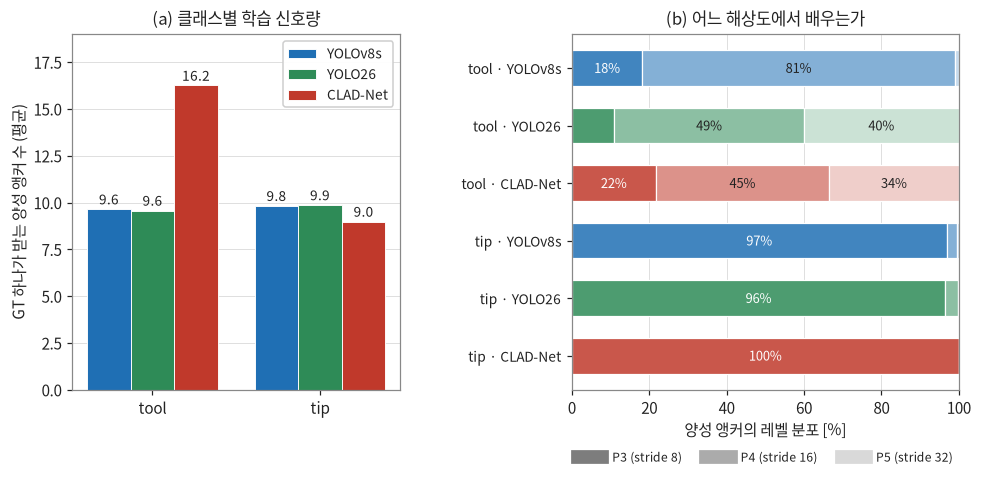

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2),
                         gridspec_kw={"width_ratios": [1.0, 1.18], "wspace": 0.48})

# (a) GT 하나가 받는 양성 앵커 수
axis = axes[0]
x = np.arange(2)
width = 0.26
for offset, model in zip(np.linspace(-width, width, len(ASSIGNED)), ASSIGNED):
    means = [np.mean(ASSIGNMENT[model]["counts"][cls]) for cls in ("0", "1")]
    bars = axis.bar(x + offset, means, width, label=LABEL[model],
                    color=COLOR[model], edgecolor="white", linewidth=0.6)
    axis.bar_label(bars, fmt="%.1f", fontsize=9, padding=2)
axis.set_xticks(x, ["tool", "tip"])
axis.set_ylabel("GT 하나가 받는 양성 앵커 수 (평균)")
axis.set_title("(a) 클래스별 학습 신호량")
axis.set_ylim(0, 19)
axis.grid(axis="y", color="#dddddd", linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(fontsize=9, framealpha=0.95, loc="upper right")

for model in ASSIGNED:
    ratio = (np.mean(ASSIGNMENT[model]["counts"]["0"])
             / np.mean(ASSIGNMENT[model]["counts"]["1"]))
    print(f"{LABEL[model]}: tool:tip = {ratio:.2f}")

# (b) 양성 앵커가 어느 레벨에 놓이는가 -- 가로 막대라 라벨을 회전하지 않아도 읽힌다
axis = axes[1]
rows = [(model, cls) for cls in ("0", "1") for model in ASSIGNED]
labels = [f"{'tool' if cls == '0' else 'tip'} · {LABEL[model]}" for model, cls in rows]
y = np.arange(len(rows))[::-1]
left = np.zeros(len(rows))
levels = ("P3 (stride 8)", "P4 (stride 16)", "P5 (stride 32)")
for level in range(3):
    widths = []
    for model, cls in rows:
        hits = ASSIGNMENT[model]["levels"][cls]
        widths.append(100.0 * hits.get(str(level), 0) / max(sum(hits.values()), 1))
    widths = np.array(widths)
    axis.barh(y, widths, 0.62, left=left,
              color=[mix(COLOR[m], "#ffffff", 0.15 + 0.30 * level) for m, _ in rows],
              edgecolor="white", linewidth=0.8)
    for index, (value, start) in enumerate(zip(widths, left)):
        if value >= 12:
            axis.text(start + value / 2, y[index], f"{value:.0f}%", ha="center", va="center",
                      fontsize=8.5, color="#ffffff" if level == 0 else INK)
    left += widths
axis.set_yticks(y, labels, fontsize=9)
axis.set_xlabel("양성 앵커의 레벨 분포 [%]")
axis.set_title("(b) 어느 해상도에서 배우는가")
axis.set_xlim(0, 100)
axis.grid(axis="x", color="#dddddd", linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(handles=[Line2D([0], [0], color=mix("#666666", "#ffffff", 0.15 + 0.30 * i),
                            linewidth=9, label=levels[i]) for i in range(3)],
            fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.24), ncol=3,
            frameon=False)

save(fig, "baseline-report-assignment")

## 그림 6 — 헝가리안 정밀도–재현율

`summary.json`의 헝가리안 매칭 결과를 거리 상한 10 / 20 / 50 px에 대해 그린다.
1:1 매칭이므로 이 좌표가 곧 **운용 지점**이다 — 그림 2의 적중률과 달리 오탐이 반영된다.

오른쪽 위로 갈수록 좋다. 같은 모델의 세 점을 잇는 선은 거리 상한을 늘렸을 때의 궤적이다.

saved docs/figures/baseline-report-precision-recall.svg
saved docs/figures/baseline-report-precision-recall.png


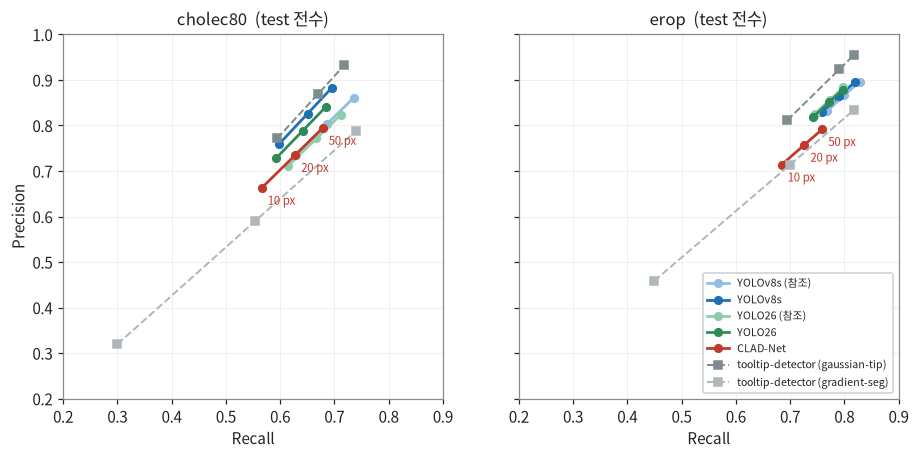

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.3), sharex=True, sharey=True)

for axis, dataset in zip(axes, DATASETS):
    for model in MODELS:
        points = [(hungarian_block(model, dataset, cap)["recall"],
                   hungarian_block(model, dataset, cap)["precision"]) for cap in (10, 20, 50)]
        recalls, precisions = zip(*points)
        style = "-o" if model in DETECTORS else "--s"
        axis.plot(recalls, precisions, style, color=COLOR[model], markersize=5,
                  linewidth=1.8 if model in DETECTORS else 1.3, label=LABEL[model])
        # 거리 상한 표시는 가장 한산한 곡선 하나에만 붙인다. 나머지 곡선도 같은 순서로
        # 10 / 20 / 50 px를 지나므로 하나만 읽으면 전부 읽힌다.
        if model == "cladnet":
            for cap, recall, precision in zip((10, 20, 50), recalls, precisions):
                axis.annotate(f"{cap} px", (recall, precision), textcoords="offset points",
                              xytext=(4, -11), fontsize=7.5, color=COLOR[model])
    axis.set_xlabel("Recall")
    axis.set_title(f"{dataset}  (test 전수)")
    axis.grid(color="#eeeeee", linewidth=0.6)
    axis.set_axisbelow(True)

axes[0].set_ylabel("Precision")
axes[0].set_xlim(0.2, 0.9)
axes[0].set_ylim(0.2, 1.0)
axes[1].legend(loc="lower right", fontsize=7, framealpha=0.95)
save(fig, "baseline-report-precision-recall")

## 그림 7 — 속도 대 정확도

가로축은 같은 GPU(RTX A6000 `cuda:2`)에서 **RGB 프레임 한 장이 상자로 바뀌기까지** 걸린
시간, 세로축은 Hit@10 px다. 표식 크기는 파라미터 수에 비례한다.

속도는 `summary.json`의 `ms_per_frame`을 쓰지 않는다. 평가를 돌린 GPU가 제각각인 데다,
그 값의 측정 구간이 계열마다 다르기 때문이다(참조 구현은 전처리까지 재고, 재구현은
letterbox 뒤부터 잰다). 아래 값은 보고서 §3.5에 적힌, 유휴 상태의 `cuda:2`에서 다섯 모델을
**같은 구간·같은 프레임**으로 다시 잰 수치다.


saved docs/figures/baseline-report-speed-accuracy.svg
saved docs/figures/baseline-report-speed-accuracy.png


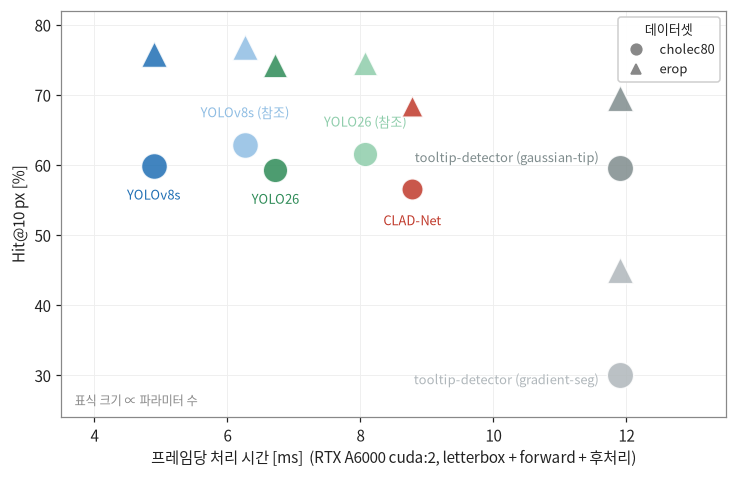

In [10]:
# 보고서 §3.5 표 10 — 같은 GPU(cuda:2), 같은 구간(RGB 프레임 -> 상자)으로 다시 잰 값.
# 루트 프로젝트의 11.9 ms는 그 보고서의 측정값을 그대로 옮긴 것이다.
LATENCY_MS = {"yolov8s": 6.26, "yolov8sclone": 4.89, "yolo26": 8.07,
              "yolo26clone": 6.72, "cladnet": 8.78,
              "gaussian-tip": 11.9, "gradient-seg": 11.9}
PARAMETERS_M = {"yolov8s": 11.14, "yolov8sclone": 11.14, "yolo26": 9.95,
                "yolo26clone": 9.95, "cladnet": 7.49,
                "gaussian-tip": 11.45, "gradient-seg": 11.45}
# 세그멘테이션 두 모델은 같은 x에 겹치므로 라벨을 반대쪽으로 뗀다
ANNOTATION = {
    "yolov8s": (0, 18, "center"),
    "yolov8sclone": (0, -22, "center"),
    "yolo26": (0, 18, "center"),
    "yolo26clone": (0, -22, "center"),
    "cladnet": (0, -24, "center"),
    "gaussian-tip": (-14, 4, "right"),
    "gradient-seg": (-14, -6, "right"),
}

fig, axis = plt.subplots(figsize=(7.8, 4.8))

for dataset, marker in zip(DATASETS, ("o", "^")):
    for model in MODELS:
        hit = tip_block(model, dataset)["hit_rate_10px_pct"]
        axis.scatter(LATENCY_MS[model], hit, s=PARAMETERS_M[model] * 26, marker=marker,
                     color=COLOR[model], alpha=0.85, edgecolor="white", linewidth=1.0, zorder=3)
        if dataset == "cholec80":
            dx, dy, align = ANNOTATION[model]
            axis.annotate(LABEL[model], (LATENCY_MS[model], hit), textcoords="offset points",
                          xytext=(dx, dy), ha=align, fontsize=8.5, color=COLOR[model])

axis.set_xlabel("프레임당 처리 시간 [ms]  (RTX A6000 cuda:2, letterbox + forward + 후처리)")
axis.set_ylabel("Hit@10 px [%]")
axis.set_xlim(3.5, 13.5)
axis.set_ylim(24, 82)
axis.grid(color="#eeeeee", linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(handles=[Line2D([0], [0], marker=m, color="#888888", linestyle="none",
                            markersize=7, label=d) for d, m in zip(DATASETS, ("o", "^"))],
            title="데이터셋", fontsize=8.5, title_fontsize=8.5, loc="upper right", framealpha=0.95)
axis.text(0.02, 0.03, "표식 크기 ∝ 파라미터 수", transform=axis.transAxes,
          fontsize=8, color="#888888")
save(fig, "baseline-report-speed-accuracy")

## 저장 결과 확인

In [11]:
for path in sorted(FIGURE_DIR.glob("baseline-report-*")):
    print(f"{path.name:<44} {path.stat().st_size / 1024:>7.1f} KB")

baseline-report-assignment.png                 118.1 KB
baseline-report-assignment.svg                  30.2 KB
baseline-report-convergence.png                166.3 KB
baseline-report-convergence.svg                 58.7 KB
baseline-report-demo.png                       265.5 KB
baseline-report-detection-ap.png               113.1 KB
baseline-report-detection-ap.svg                29.0 KB
baseline-report-error-distribution.png         169.1 KB
baseline-report-error-distribution.svg          42.3 KB
baseline-report-hit-curve.png                  165.9 KB
baseline-report-hit-curve.svg                   41.5 KB
baseline-report-precision-recall.png           123.6 KB
baseline-report-precision-recall.svg            41.5 KB
baseline-report-speed-accuracy.png              93.2 KB
baseline-report-speed-accuracy.svg              22.4 KB
